# Sklearn Example

### Breast cancer dataset

In [2]:
# some useful imports
#!pip install scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [14]:
# load the breast cancer dataset
data = load_breast_cancer()
X = data.data
print(X.shape)
print(X[:10,:])
y = data.target
print(y.shape)

(569, 30)
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01 2.839

In [8]:
# embedding to see separability:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X)
X_embedded.shape

(569, 2)

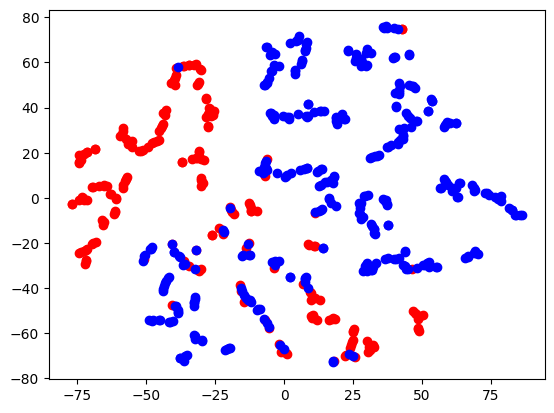

In [13]:
# plot
fig, ax = plt.subplots()
ax.scatter(X_embedded[y==0,0], X_embedded[y==0,1], color = "red", label = "0")
ax.scatter(X_embedded[y==1,0], X_embedded[y==1,1], color = "blue", label = "1")
plt.show()

In [16]:
# Scale the features to the range 0 to 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [17]:
# Naive Bayes classifier
naive_bayes_clf = GaussianNB()
naive_bayes_clf.fit(X_train, y_train)
naive_bayes_pred = naive_bayes_clf.predict(X_test)
naive_bayes_accuracy = accuracy_score(y_test, naive_bayes_pred)

In [18]:
# Logistic Regression
logistic_reg_clf = LogisticRegression()
logistic_reg_clf.fit(X_train, y_train)
logistic_reg_pred = logistic_reg_clf.predict(X_test)
logistic_reg_accuracy = accuracy_score(y_test, logistic_reg_pred)

In [19]:
# Neural Network with 2 layers
neural_network_clf = MLPClassifier(hidden_layer_sizes=(20, 20), activation='logistic', random_state=42)
neural_network_clf.fit(X_train, y_train)
neural_network_pred = neural_network_clf.predict(X_test)
neural_network_accuracy = accuracy_score(y_test, neural_network_pred)

C:\Users\rvalente6\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Naive Bayes Classifier Accuracy: 0.9649122807017544
Logistic Regression Accuracy: 0.9824561403508771
Neural Network Accuracy: 0.9736842105263158


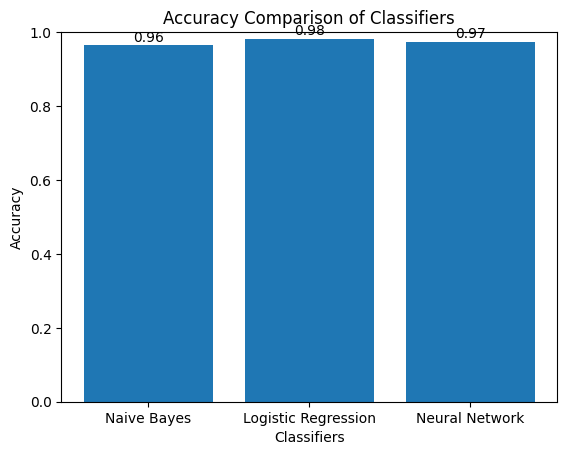

In [20]:
# Print the accuracies of each classifier
print("Naive Bayes Classifier Accuracy:", naive_bayes_accuracy)
print("Logistic Regression Accuracy:", logistic_reg_accuracy)
print("Neural Network Accuracy:", neural_network_accuracy)

# Accuracy values
accuracy_values = [naive_bayes_accuracy, logistic_reg_accuracy, neural_network_accuracy]

# Classifier names
classifiers = ['Naive Bayes', 'Logistic Regression', 'Neural Network']

# Create bar plot
plt.bar(classifiers, accuracy_values)
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Classifiers')
plt.ylim([0, 1])  # Set the y-axis limit between 0 and 1

# Display the accuracy values on top of each bar
for i, v in enumerate(accuracy_values):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center')
plt.show()